<a href="https://colab.research.google.com/github/caviteri/Ciencia-de-Datos-2026/blob/main/Ciencia_de_Datos_Semana_06_Caminata_Aleatoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Taller Práctico: Simulación de una Caminata Aleatoria**

Maestría en Ingeniería Electrónica (MaIE)

Universidad de Nariño Curso

Introducción a la Ciencia de Datos

Instructor: Carlos Andrés Viteri Mera

En este cuaderno construiremos un simulador computacional para analizar un proceso de caminata aleatoria simple en tiempo discreto. Este proceso, útil en el modelado financiero y de dinámica de partículas, es un ejemplo clásico de un proceso estocástico, particularmente de un proceso de Markov.

A partir de la generación de $M$ realizaciones empíricas independientes del proceso, estimaremos sus principales métricas estadísticas en cada paso de tiempo $n\in\{0,1,…,N\}$ y las compararemos con sus propiedades matemáticas teóricas.


In [1]:
# Importamos las librarías de computación numérica (numpy) y de gráficas
# matemáticas (matplotlib)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# **1. Simulación de M realizaciones de una caminata aleatoria**

La caminata aleatoria se define como la suma acumulada de variables aleatorias independientes e idénticamente distribuidas (iids). En la caminata aleatoria simple, los pasos toman valores $Y[n]​\in\{−1,+1\}, \ n=1,\ldots,N$, con probabilidad $p = 0.5$ para cada valor.

El estado en el paso $n$ se define como: $X[n] ​= X[n−1]​+Y[n]​=\sum_{i=1}^n ​Y[i]​$, y se asume que $X[0]​=0$.
A continuación, generaremos un ensamble (conjunto de realizaciones) de $M$ trayectorias de $N$ pasos.

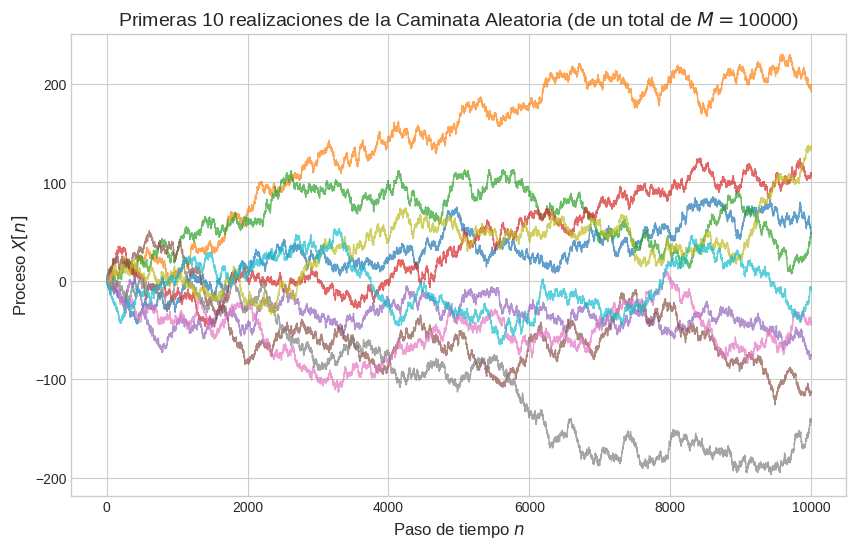

In [2]:
# Parámetros de la simulación
M = 10000  # Número de realizaciones (trayectorias)
N = 10000   # Número de pasos de tiempo (n = 0, 1, ..., N)

#np.random.seed(42) # Semilla para reproducibilidad

# 1. Generamos los M x N pasos aleatorios (-1 o 1 con igual probabilidad)
# Usamos binomial para obtener 0 o 1, multiplicamos por 2 y restamos 1 para
# llevar los datos a los dos valores posibles -1 y 1
pasos = np.random.binomial(n=1, p=0.5, size=(M, N)) * 2 - 1

# 2. Inicializamos la matriz de realizaciones (X[0] = 0 para todos)
X = np.zeros((M, N + 1))

# 3. Calculamos la suma acumulada en el eje del tiempo (eje 1) para obtener la
# posición en X_n
X[:, 1:] = np.cumsum(pasos, axis=1)

# 4. Visualizamos las primeras 10 trayectorias
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.plot(range(N + 1), X[i, :], alpha=0.7, lw=1)

plt.title(f'Primeras 10 realizaciones de la Caminata Aleatoria (de un total de $M=${M})', fontsize=14)
plt.xlabel('Paso de tiempo $n$', fontsize=12)
plt.ylabel('Proceso $X[n]$', fontsize=12)
plt.show()


# **2. Valor Esperado y Varianza Empírica**
De la teoría de procesos estocásticos sabemos que el valor esperado es el primer momento probabilístico, $\mu[n]=E\{X[n]\}$. Dado que los incrementos son $\pm 1$, para la caminata aleatoria se cumple teóricamente que $E\{X[n​]\}=0$ para todo $n$. Además, la varianza empírica $\mathrm{var}\{X[n]\}$ representa la potencia promedio del proceso cuando la media es cero. Teóricamente, en una caminata aleatoria simple, la varianza crece linealmente con el tiempo: $\mathrm{var}\{X[n]\}=n$. Evaluemos empíricamente promediando a través de las $M$ realizaciones para cada instante $n$.

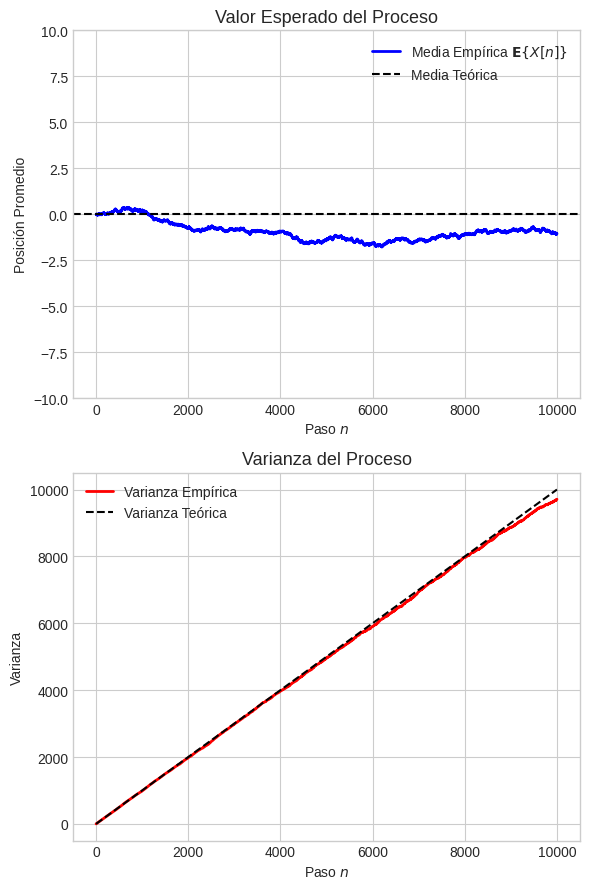

In [3]:
# 1. Valor esperado empírico (media transversal sobre las M realizaciones)
mu_empirica = np.mean(X, axis=0)

# 2. Varianza empírica (varianza transversal sobre las M realizaciones)
var_empirica = np.var(X, axis=0)

n_array = np.arange(N + 1)

# Visualización comparativa
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))

# Gráfica del Valor Esperado
ax1.plot(n_array, mu_empirica, label=r'Media Empírica $\mathbf{E}\{ X[n] \}$', color='blue', lw=2)
ax1.axhline(0, color='black', linestyle='--', label='Media Teórica')
ax1.set_title('Valor Esperado del Proceso', fontsize=13)
ax1.set_xlabel('Paso $n$')
ax1.set_ylabel('Posición Promedio')
ax1.set_ylim(-10, 10)
ax1.legend()

# Gráfica de la Varianza
ax2.plot(n_array, var_empirica, label='Varianza Empírica', color='red', lw=2)
ax2.plot(n_array, n_array, color='black', linestyle='--', label='Varianza Teórica')
ax2.set_title('Varianza del Proceso', fontsize=13)
ax2.set_xlabel('Paso $n$')
ax2.set_ylabel('Varianza')
ax2.legend()

plt.tight_layout()
plt.show()

# **4. Estimación de la Función de Densidad de Probabilidad (PDF) en el tiempo**
Para un proceso estocástico $X[n]$ en un instante $n$ fijo, $X[n]$ es una variable aleatoria caracterizada por su función de densidad de probabilidad $f_X​(x,n)$.
Dado que la varianza de la caminata aleatoria crece con el tiempo ($\mathrm{var}\{X[n]\}=n$), la dispersión de la PDF también debe aumentar a medida que avanzan los pasos. A continuación, estimaremos y graficaremos la PDF empírica de la posición $X[n]$​ basándonos en las $M$ realizaciones para los instantes $n=1$, $n=5$ y $n=N$.

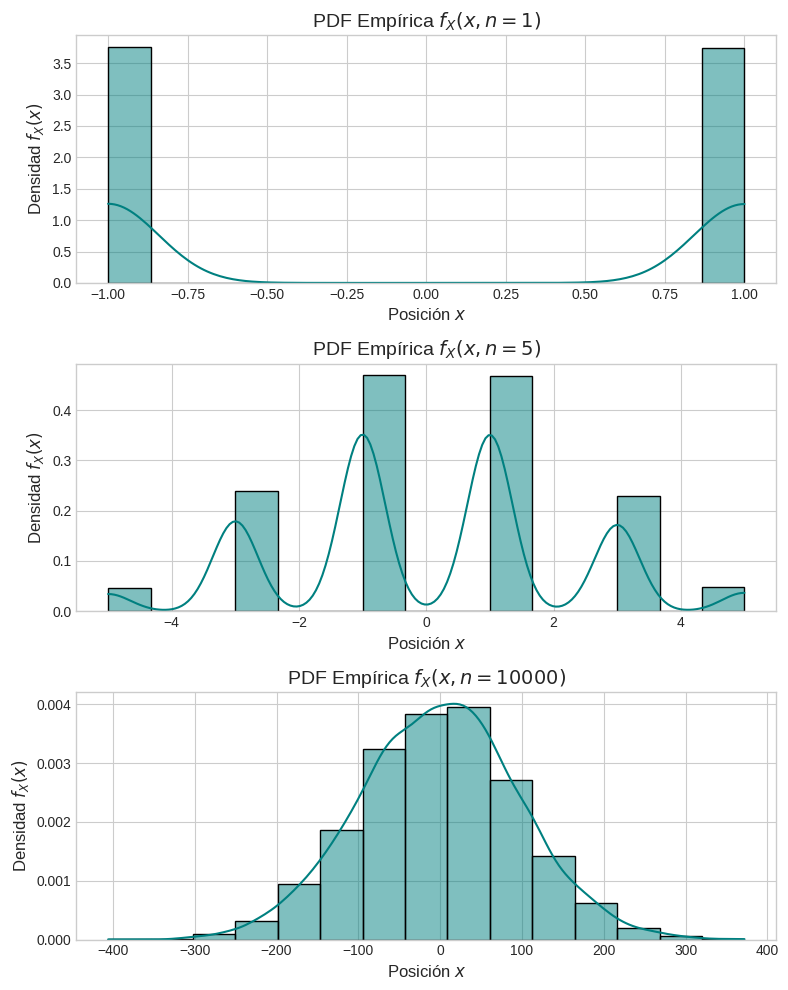

In [4]:
# Definimos los pasos de tiempo a evaluar
pasos_a_evaluar = [1, 5, N]

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i, n_step in enumerate(pasos_a_evaluar):
    # Extraemos transversalmente la posición de las M realizaciones en el paso n_step
    X_en_t = X[:, n_step]

    # Estimamos la PDF empírica usando un histograma y estimación de densidad de kernel (KDE)
    sns.histplot(X_en_t, kde=True, stat="density", ax=axes[i], color='teal', bins=15)

    axes[i].set_title(f'PDF Empírica $f_X(x, n={n_step})$', fontsize=14)
    axes[i].set_xlabel('Posición $x$', fontsize=12)
    axes[i].set_ylabel('Densidad $f_X(x)$', fontsize=12)

    # Fijamos el límite del eje X basado en el paso final N para observar cómo crece la dispersión
    #axes[i].set_xlim([-np.sqrt(N)*3, np.sqrt(N)*3])

plt.tight_layout()
plt.show()

# Análisis:
# Se observa cómo la dispersión (varianza) de la PDF aumenta con n.
# Para n=1, X_1 solo toma valores en -1 y 1. Para n=N, la distribución se asemeja
# cada vez más a una campana gaussiana (por el Teorema del Límite Central).

# **3. Función de Autocorrelación y Autocovarianza (Empíricas)**

La función de autocorrelación, definida formalmente como $R_{XX}[​n_1​,n_2]\triangleq \mathbf{E} \{ X[n_1]X[n_2] \}$, mide la relación temporal del proceso consigo mismo en dos instantes de tiempo distintos.

La autocovarianza descuenta la media del proceso y se define como $C_{XX}​[​n_1​,n_2]=R_{XX}[​n_1​,n_2]−\mu[n_1]\mu[n_2]$. Dado que $\mu[n]=0$, $\forall n$ para la caminata aleatoria, la autocorrelación y la autocovarianza son iguales. Se puede demostrar que $R_{XX}[​n_1​,n_2] = C_{XX}[​n_1​,n_2]=\min(n_1​,n_2​)$.
Fijaremos un instante particular $n_1​=5000$ y calcularemos estas funciones empíricas variando $n_2$​ desde $0$ hasta $N$.


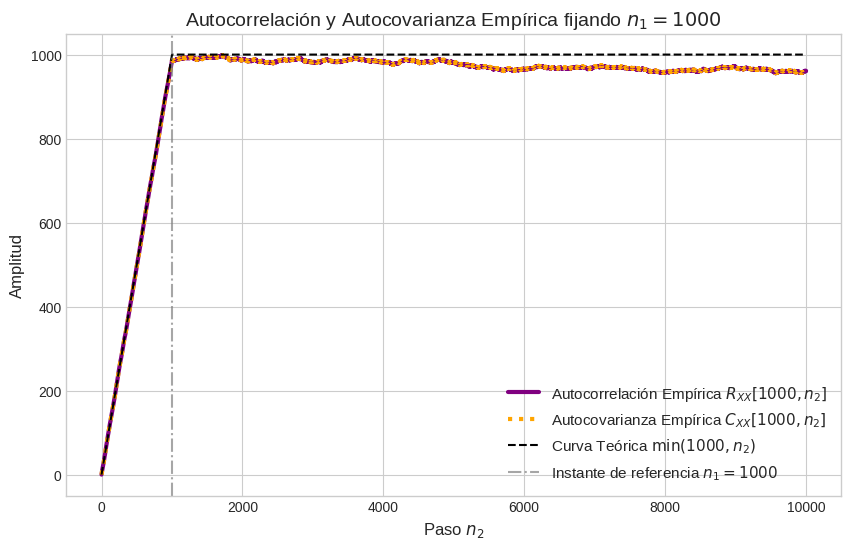

Observamos que para n_2 < n_1 (1000), la correlación empírica crece con n_2.
Para n_2 >= n_1 (1000), el valor se satura y oscila empíricamente alrededor del nivel teórico 1000.
Además, los valores de R_XX y C_XX son aproximadamente iguales porque la media del proceso tiende a cero.


In [5]:
n1 = 1000
R_XX_empirica = np.zeros(N + 1)
C_XX_empirica = np.zeros(N + 1)

# Cálculo a través del ensamble de las M realizaciones
for n2 in range(N + 1):
    # Autocorrelación: Esperanza del producto E[X(t1)*X(t2)]
    R_XX_empirica[n2] = np.mean(X[:, n1] * X[:, n2])

    # Autocovarianza: R_XX(t1,t2) - mu(t1)*mu(t2)
    C_XX_empirica[n2] = R_XX_empirica[n2] - (mu_empirica[n1] * mu_empirica[n2])

# Autocorrelación / Autocovarianza Teórica para Caminata Aleatoria es min(t1, t2)
R_XX_teorica = [min(n1, n2) for n2 in range(N + 1)]

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(range(N + 1), R_XX_empirica, label=f'Autocorrelación Empírica $R_{{XX}}[{n1}, n_2]$', color='purple', lw=3)
plt.plot(range(N + 1), C_XX_empirica, label=f'Autocovarianza Empírica $C_{{XX}}[{n1}, n_2]$', color='orange', linestyle=':', lw=3)
plt.plot(range(N + 1), R_XX_teorica, label=f'Curva Teórica $\\min({n1}, n_2)$', color='black', linestyle='--')

plt.axvline(n1, color='gray', linestyle='-.', alpha=0.7, label=f'Instante de referencia $n_1 = {n1}$')

plt.title(f'Autocorrelación y Autocovarianza Empírica fijando $n_1 = {n1}$', fontsize=14)
plt.xlabel('Paso $n_2$', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend(fontsize=11)
plt.show()

# Análisis final
print(f"Observamos que para n_2 < n_1 ({n1}), la correlación empírica crece con n_2.")
print(f"Para n_2 >= n_1 ({n1}), el valor se satura y oscila empíricamente alrededor del nivel teórico {n1}.")
print("Además, los valores de R_XX y C_XX son aproximadamente iguales porque la media del proceso tiende a cero.")


# **5. Función de Autocovarianza $C_{XX}​[n_1​,n_2​]$ en 2D**

La función de autocovarianza mide la dependencia lineal entre el proceso en dos instantes de tiempo diferentes y se define teóricamente como $C_{XX}​[n_1,n_2]=\mathbf{E}\{(X[n_1]−\mu[n_1])( X[n_2]−\mu[n_2])\}$.

Calcularemos la matriz de covarianza cruzada empírica para todas las combinaciones posibles de $​[n_1,n_2]$ en el rango $[0,N]$. El resultado lo visualizaremos en un mapa de calor (gráfico 2D con escala de colores), donde teóricamente deberíamos observar el comportamiento $C_{XX}​[n_1,n_2]=\min​[n_1,n_2]$.

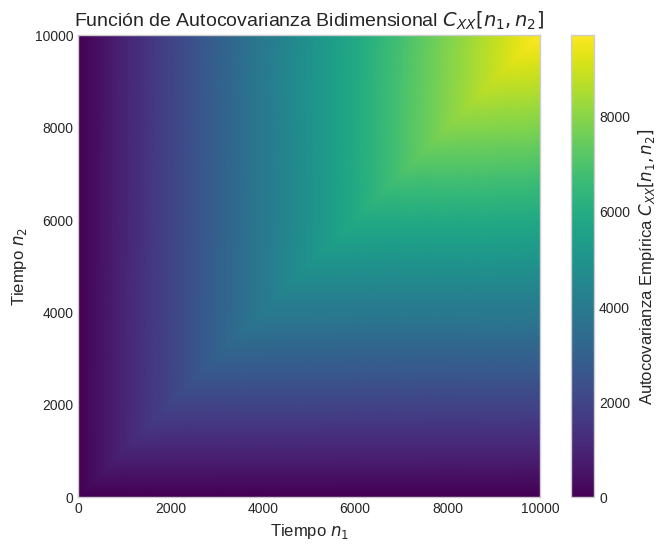

In [6]:
# Calculamos la matriz de covarianza empírica de dimensión (N+1) x (N+1)
# np.cov asume por defecto que las filas son variables y columnas observaciones,
# por lo que usamos rowvar=False para que calcule la covarianza entre las columnas (los tiempos t)
C_XX_matriz = np.cov(X, rowvar=False)

# Visualización de la función de autocovarianza en un gráfico 2D con mapa de colores
plt.figure(figsize=(8, 6))

# origin='lower' asegura que el origen (0,0) esté en la esquina inferior izquierda
img = plt.imshow(C_XX_matriz, origin='lower', cmap='viridis', extent=[0, N, 0, N])

# Agregamos la barra de colores que representa la magnitud de la autocovarianza
cbar = plt.colorbar(img)
cbar.set_label('Autocovarianza Empírica $C_{XX}​[n_1,n_2]$', fontsize=12)

# Etiquetas y formato
plt.title('Función de Autocovarianza Bidimensional $C_{XX}​[n_1,n_2]$', fontsize=14)
plt.xlabel('Tiempo $n_1$', fontsize=12)
plt.ylabel('Tiempo $n_2$', fontsize=12)
plt.grid(False) # Apagamos la cuadrícula para ver mejor los colores
plt.show()

# Análisis:
# La diagonal de abajo a la izquierda hacia arriba a la derecha (donde n1 = n2)
# representa la varianza del proceso en ese instante: C_XX(n, n) = var(X[n]) = n.
# Como se observa en la escala de colores, el valor crece a medida que avanzamos en la diagonal,
# llegando a su máximo en (N, N), confirmando empíricamente que var(X_N) ≈ N.